In [1]:
import CONSTANTS
from functions import *
import warnings
import torch
import torch.nn as nn
import math
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from transformer_classes import *
from tqdm import tqdm
from sklearn.metrics import *

warnings.filterwarnings('ignore')

# Transformer

Objective: predict change in BTC price given features

## Prepare data
Create tupled dataset


In [2]:
RESPONSE = 'close'

In [4]:
data = pd.read_csv(f'../{fullDataPath('BTC')}')
daily_data = dataSetup(data, trainingColPath='../training_columns.txt')
daily_data

,SMA_7,OBV,BB_Lower,BB_Upper,value,close,gradient
time,,,,,,,
2015-07-20,283.615714,-3.764197e+06,268.225209,299.188791,48.0,280.00,0.00
2015-07-21,285.645714,-3.764980e+06,266.070954,300.106046,48.0,277.32,-2.68
2015-07-22,288.280000,-3.760037e+06,263.804410,301.155590,48.0,277.89,0.57
2015-07-23,290.037143,-3.764725e+06,263.024045,301.345955,48.0,277.39,-0.50
2015-07-24,291.622857,-3.759418e+06,261.412051,301.912949,48.0,289.12,11.73
...,...,...,...,...,...,...,...
2025-06-22,104624.465714,-1.547980e+04,101255.903690,110442.214310,40.0,100996.87,-1163.16
2025-06-23,104624.465714,-7.607546e+03,101255.903690,110442.214310,37.0,105419.39,4422.52
2025-06-24,104624.465714,1.297079e+03,101255.903690,110442.214310,47.0,106141.00,721.61


<Axes: title={'center': 'BTC Price'}, xlabel='Date', ylabel='Price (USD)'>

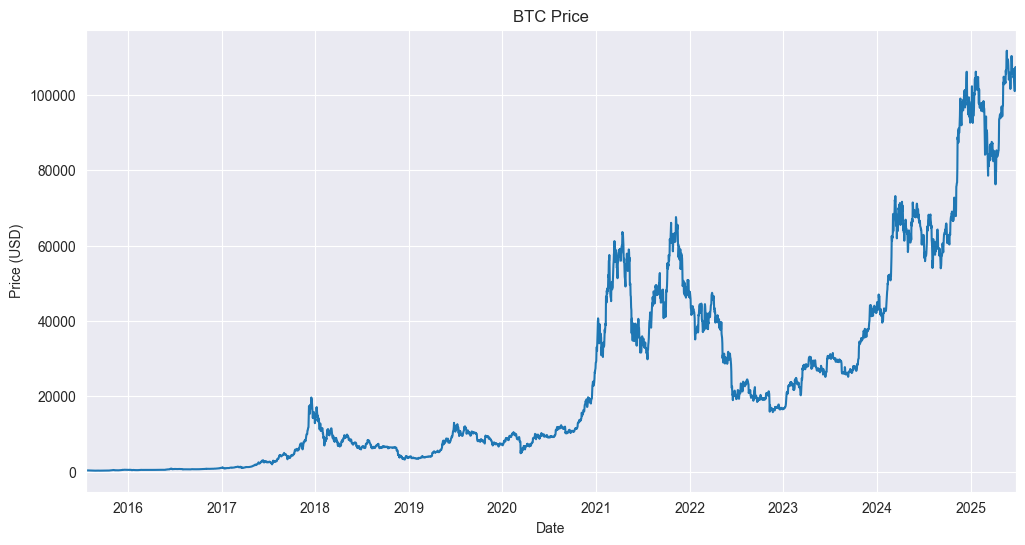

In [5]:
daily_data[RESPONSE].plot.line(title=f'{COIN} Price', figsize=(12, 6), ylabel='Price (USD)', xlabel='Date')

<Axes: ylabel='Frequency'>

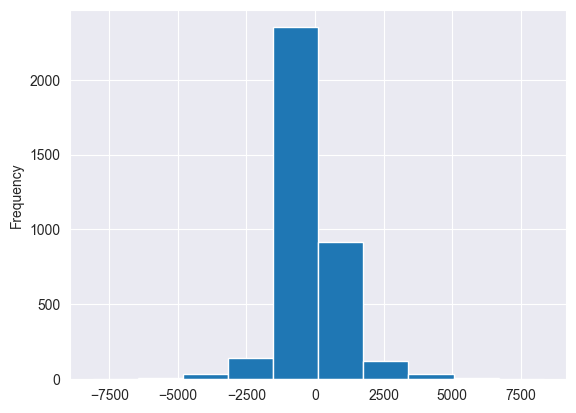

In [6]:
daily_data['gradient'].plot.hist()

In [7]:
daily_data[RESPONSE].describe()

count      3630.000000
mean      24918.504347
std       27101.522397
min         211.160000
25%        4202.680000
50%       11368.985000
75%       39738.017500
max      111722.530000
Name: close, dtype: float64

# Load the Transformer Model

Sequence the data to make it predict the next price

## Preprocess the data


In [8]:
daily_data = transformerDataSetup(daily_data)
daily_data[['sequence', 'next']]

,sequence,next
time,,
2015-07-20,"[-99999999.0, -99999999.0, -99999999.0, -99999...",277.32
2015-07-21,"[280.0, -99999999.0, -99999999.0, -99999999.0,...",277.89
2015-07-22,"[280.0, 277.32, -99999999.0, -99999999.0, -999...",277.39
2015-07-23,"[280.0, 277.32, 277.89, -99999999.0, -99999999...",289.12
2015-07-24,"[280.0, 277.32, 277.89, 277.39, -99999999.0, -...",289.70
...,...,...
2025-06-22,"[280.0, 277.32, 277.89, 277.39, 289.12, 289.7,...",105419.39
2025-06-23,"[280.0, 277.32, 277.89, 277.39, 289.12, 289.7,...",106141.00
2025-06-24,"[280.0, 277.32, 277.89, 277.39, 289.12, 289.7,...",107400.22


## Load the Model

### Data Setup

In [22]:
from sklearn.preprocessing import StandardScaler
DAYS_TO_PREDICT = 7
X_train, X_test, y_train, y_test, _, _ = transformerXTrainYTrain(daily_data, testSize=len(daily_data)-DAYS_TO_PREDICT)
X_train_norm, X_test_norm, y_train_norm, y_test_norm, sequence_scaler, target_scaler = normalize(X_train, X_test, y_train, y_test)

In [13]:
model = torch.load(f'../models/{COIN}_model2.pth')

In [18]:
# Create model with appropriate settings for Bitcoin prediction
model = BaseTransformer(
    d_model=128,
    num_heads=8,
    num_layers=4,
    learning_rate=1e-4,  # This is fine now with normalized data
    batch_size=32,
    dropout=0.1,
    mask_value=FILL
)
model.fit(X_train_norm, y_train_norm, epochs=30, validation_data=(X_test_norm, y_test_norm))
torch.save(model, f'../models/{COIN}_model.pth')

Data shapes - X: torch.Size([358, 365, 1]), y: torch.Size([358, 1])
DataFrame column: sequences
Sample sequence length: 365


Training Progress:   0%|          | 0/30 [00:07<?, ?it/s]


KeyboardInterrupt: 

In [17]:
model = torch.load(f'../models/{COIN}_full_model.pth')

predictions = model.predict(X_test_norm)
predictions = target_scaler.inverse_transform(predictions).reshape(-1)
predictions = pd.Series(predictions, index=y_test.index)
y_test_norm.index = X_test_norm.index

rmse = root_mean_squared_error(y_test, predictions)
print(f"Test RMSE: {rmse:.4f}")

Test RMSE: 4615.5275


<Axes: title={'center': 'Difference on Prediction and Actual'}, xlabel='time'>

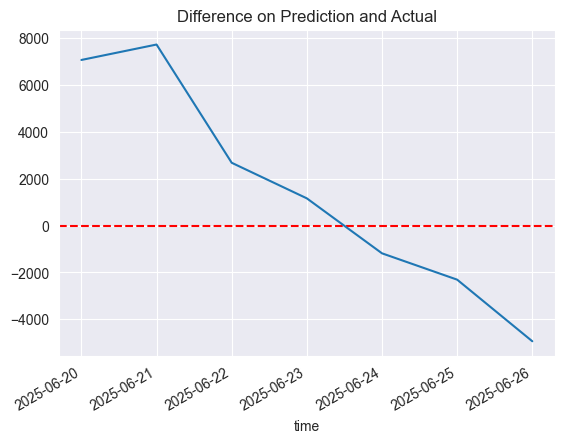

In [18]:
diff = predictions - y_test
plt.axhline(0.0, color='r', linestyle='--')
diff.plot.line(title='Difference on Prediction and Actual')

<Axes: title={'center': 'Predicted vs. Actual Value on Validation Month'}, xlabel='Date', ylabel='Price'>

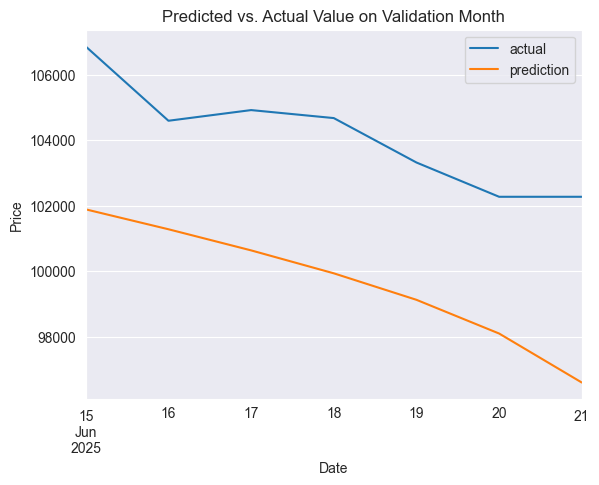

In [21]:
comparison = pd.concat([y_test, predictions], axis=1)
comparison.columns = ['actual', 'prediction']
comparison.plot.line(title='Predicted vs. Actual Value on Validation Month', xlabel='Date', ylabel='Price')

In [33]:
new = daily_data[RESPONSE].iloc[-30:]
new, next = sequence(new, len(new)-1)
new = pd.DataFrame({'sequences': [new]})
new = pd.DataFrame({""
        'sequences': normalize_sequences(new.iloc[:, 0], sequence_scaler)
    })
model.predict(new, sequence_scaler)[0, 0]

106165.69

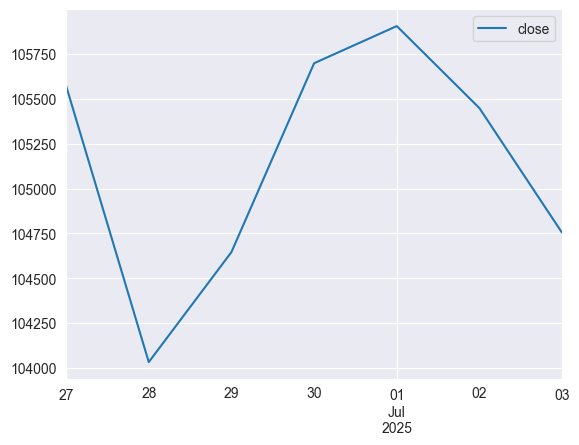

In [28]:
price = daily_data[RESPONSE].iloc[-1]
starter = daily_data[RESPONSE].iloc[-30:]
predictions = predict_sequence(model, price, starter, sequence_scaler, sequence_length=7)
new_days = pd.date_range(start=daily_data.index[-1] + pd.Timedelta(days=1), periods=len(predictions), freq='D')
predictions_df = pd.DataFrame(predictions, index=new_days, columns=[RESPONSE])
predictions_df.plot.line()
plt.show()

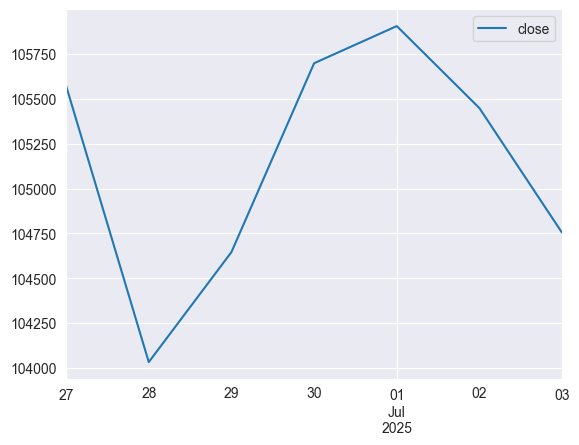

,close
2025-06-27,105572.58
2025-06-28,104033.26
2025-06-29,104645.87
2025-06-30,105697.94
2025-07-01,105904.94
2025-07-02,105447.82
2025-07-03,104753.38


In [32]:
predictNextNDaysTransformer(daily_data, total_length=365)